In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from model import PositionalEncoding
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import math

### VOCABULARY


In [77]:
PAD = 0
SOS = 1
EOS = 2

# Because of PAD SOS EOS, shift all numbers by 3
SHIFT = 3

VOCAB_SIZE = 104  # PAD, SOS, EOS, Numbers 0...100

In [78]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, h, dropout=0.1):
        super().__init__()
        assert d_model % h == 0, "d_model must be divisible by num_heads"

        self.h = h
        self.d_k = d_model // h

        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        n_samples, seq_len, d_model = x.size()

        # (n_samples, seq_len, d_model)
        Q = self.W_Q(x)
        K = self.W_K(x)
        V = self.W_V(x)

        # (n_samples, seq_len, h, d_k)
        Q = Q.view(n_samples, seq_len, self.h, self.d_k)
        K = K.view(n_samples, seq_len, self.h, self.d_k)
        V = V.view(n_samples, seq_len, self.h, self.d_k)

        # Swap h and seq_len, matmul only works on last 2 dimensions
        # (n_samples, h, seq_len, d_k)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        qkt = Q @ K.transpose(2, 3)  # (n_samples, h, seq_len, seq_len)
        scores = qkt / math.sqrt(self.d_k)

        # Fills elements where mask is True to -inf
        if mask is not None:
            # (seq_len, seq_len) -> (1, 1, seq_len, seq_len) for batch, n_samples broadcasting
            mask = mask.unsqueeze(0).unsqueeze(0).to(x.device)
            scores = scores.masked_fill(mask, float('-inf'))

        weights = self.dropout(F.softmax(scores, dim=-1))

        self.attn_weights = weights.detach()

        output = weights @ V  # (n_samples, h, seq_len, d_k)

        # (n_samples, seq_len, d_model)
        concat = output.transpose(1, 2).contiguous().view(
            n_samples, seq_len, d_model)

        return self.W_O(concat)

In [33]:
~torch.tril(torch.ones((4, 4), dtype=torch.bool))

tensor([[False,  True,  True,  True],
        [False, False,  True,  True],
        [False, False, False,  True],
        [False, False, False, False]])

In [79]:
def fib(n_samples, seq_len, max_value):
    dataset = []
    for _ in range(n_samples):
        a, b = torch.randint(1, 10, (2,)).tolist()
        seq = [a, b]
        for _ in range(seq_len - 2):
            next_val = seq[-1] + seq[-2]
            if next_val > max_value:
                break
            seq.append(next_val)

        dataset.append(seq)

    return dataset


fib(3, 10, 100)

[[9, 8, 17, 25, 42, 67],
 [4, 8, 12, 20, 32, 52, 84],
 [1, 2, 3, 5, 8, 13, 21, 34, 55, 89]]

In [ ]:
def prepare_fib_sequence(seq, seq_len):
    seq = [x + SHIFT for x in seq]

    full_seq = [SOS] + seq + [EOS]

    decoder_input = full_seq[:-1]
    target = full_seq[1:]

    padding_needed = seq_len - len(decoder_input)
    if padding_needed > 0:
        decoder_input += [PAD] * padding_needed
        target += [PAD] * padding_needed
    else:
        # Trim if they exceed seq_len
        decoder_input = decoder_input[:seq_len]
        target = target[:seq_len]

    return torch.tensor(decoder_input), torch.tensor(target)


seq = fib(1, 10, 100)[0]
print(seq)
prepare_fib_sequence(seq, 10)

[8, 5, 13, 18, 31, 49, 80]


(tensor([ 1, 11,  8, 16, 21, 34, 52, 83,  0,  0]),
 tensor([11,  8, 16, 21, 34, 52, 83,  2,  0,  0]))

In [81]:
class FibDataset(Dataset):
    def __init__(self, n_samples, seq_len, max_value):
        self.max_value = max_value
        self.seq_len = seq_len

        # generate Fibonacci sequences
        self.data = fib(n_samples, seq_len, max_value)  # list of lists

    def __getitem__(self, index):
        raw_seq = self.data[index]
        seq = [x + SHIFT for x in raw_seq]

        full_seq = [SOS] + seq + [EOS]

        X = full_seq[:-1]
        Y = full_seq[1:]

        pad_len = self.seq_len - len(X)
        if pad_len > 0:
            X += [PAD] * pad_len
            Y += [PAD] * pad_len
        else:
            X = X[:self.seq_len]
            Y = Y[:self.seq_len]

        return torch.tensor(X), torch.tensor(Y)

    def __len__(self):
        return len(self.data)

In [82]:
fibds = FibDataset(10, 10, 100)

fibds[6]

(tensor([ 1,  9,  6, 12, 15, 24, 36, 57, 90,  0]),
 tensor([ 9,  6, 12, 15, 24, 36, 57, 90,  2,  0]))

In [83]:
train_dataset = FibDataset(20000, 10, 99)
val_dataset = FibDataset(2000, 10, 99)
test_dataset = FibDataset(2000, 10, 99)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False
)

In [84]:
train_dataset[2]

(tensor([ 1,  4,  9, 10, 16, 23, 36, 56, 89,  0]),
 tensor([ 4,  9, 10, 16, 23, 36, 56, 89,  2,  0]))

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, d_model, h, d_ff, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, h, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        seq_len = x.shape[1]

        mask = ~torch.tril(torch.ones((seq_len, seq_len), dtype=torch.bool))

        norm_x = self.norm1(x)
        mha_out = self.mha(norm_x, mask)
        x = x + self.dropout(mha_out)

        norm_x = self.norm2(x)
        ff_out = self.ff(norm_x)
        x = x + self.dropout(ff_out)

        # (batch, seq_len, dims)
        return x

In [106]:
class TransformerFib(nn.Module):
    def __init__(self, vocab_size, d_model, seq_len, num_heads, num_layers):
        super().__init__()

        self.emb = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(seq_len, d_model)
        self.layers = nn.ModuleList([
            DecoderBlock(d_model, num_heads, num_heads * 4) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.emb(x)
        x = self.pos_encoding(x)

        for layer in self.layers:
            x = layer(x)

        x = self.fc_out(x)
        return x

In [136]:
model = TransformerFib(
    vocab_size=VOCAB_SIZE,
    d_model=512,
    seq_len=10,
    num_heads=4,
    num_layers=4
)
device = 'cpu'
criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [124]:
def train(model, dataloader):
    model.train()
    total_loss = 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)

        logits = model(x)

        loss = criterion(logits.view(-1, VOCAB_SIZE), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [ ]:
def validate(model, dataloader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits = model(inputs)

            loss = criterion(logits.view(-1, VOCAB_SIZE), targets.view(-1))
            total_loss += loss.item()

            predictions = torch.argmax(logits, dim=-1)
            mask = (targets != 0)

            # ignore the first two positions (seeds for fib pattern)
            mask[:, :2] = False

            correct += ((predictions == targets) & mask).sum().item()
            total += mask.sum().item()

    return total_loss / len(dataloader), (correct / total) * 100

In [137]:
epochs = 5
best_val_loss = float('inf')
for epoch in range(epochs):
    train_loss = train(
        model,
        train_loader,
    )
    val_loss, val_acc = validate(
        model,
        val_loader,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')

    print(
        f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

Epoch 01 | Train Loss: 1.1715 | Val Loss: 0.5471 | Val Acc: 100.00%
Epoch 02 | Train Loss: 0.5542 | Val Loss: 0.5271 | Val Acc: 100.00%
Epoch 03 | Train Loss: 0.5364 | Val Loss: 0.5207 | Val Acc: 100.00%
Epoch 04 | Train Loss: 0.5313 | Val Loss: 0.5198 | Val Acc: 100.00%
Epoch 05 | Train Loss: 0.5273 | Val Loss: 0.5210 | Val Acc: 100.00%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch


def plot_attention_heads(attn_tensor, tokens):
    # Remove batch dimension
    attn = attn_tensor.squeeze(0).cpu().detach().numpy()
    num_heads = attn.shape[0]

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i in range(num_heads):
        sns.heatmap(
            attn[i],
            xticklabels=tokens,
            yticklabels=tokens,
            vmin=0, vmax=1,  # Probabilities are between 0 and 1
            cmap='viridis',
            annot=True,  # Shows the actual probability values
            fmt=".2f",
            ax=axes[i]
        )
        axes[i].set_title(f"Head {i+1}")
        axes[i].set_xlabel("Keys (Looking Back At)")
        axes[i].set_ylabel("Queries (Predicting Next)")

    plt.tight_layout()
    plt.suptitle("Multi-Head Attention Maps (Fibonacci Logic)",
                 fontsize=20, y=1.02)
    plt.show()

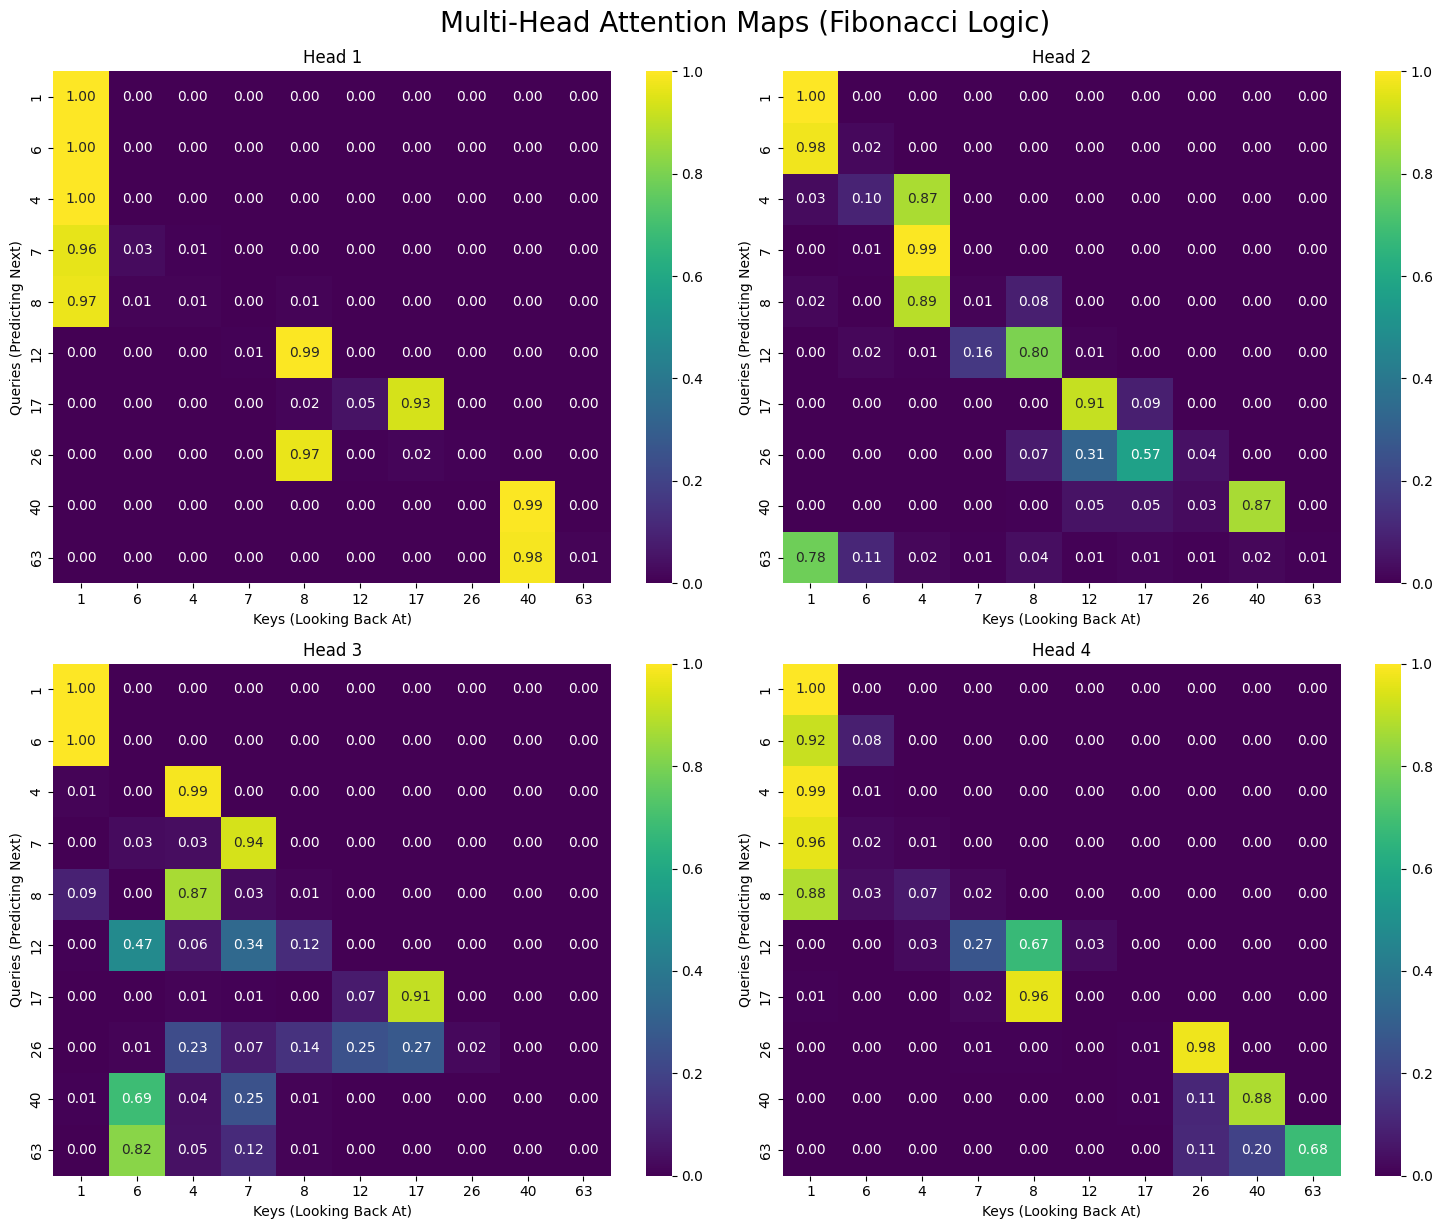

In [139]:
x_sample, y_sample = val_dataset[0]

saved_attention = []


def hook_fn(module, input, output):
    if hasattr(module, 'attn_weights'):
        saved_attention.append(module.attn_weights.cpu())


handle = model.layers[-1].mha.register_forward_hook(hook_fn)
model.eval()
with torch.no_grad():
    model(x_sample.unsqueeze(0).to(device))
handle.remove()

weights = saved_attention[0]

plot_attention_heads(weights, x_sample.tolist())

In [ ]:
def generate_fibonacci(model, seed_numbers, max_len=10, device='cpu'):
    model.eval()

    # Apply SHIFT and add SOS token
    tokens = [SOS] + [num + SHIFT for num in seed_numbers]
    input_tensor = torch.tensor([tokens]).to(device)  # (1, current_len)

    for _ in range(max_len - len(tokens)):
        with torch.no_grad():
            logits = model(input_tensor)

            # last token's logits
            next_token_logits = logits[0, -1, :]
            next_token = torch.argmax(next_token_logits).item()

            # break if model predicts EOS
            if next_token == EOS:
                break

            # Append the predicted token to the input for the next step
            input_tensor = torch.cat(
                [input_tensor, torch.tensor([[next_token]]).to(device)], dim=1)
            tokens.append(next_token)

    # skip SOS (index 0), then subtract SHIFT from everything else
    raw_output = [t - SHIFT for t in tokens[1:]]
    return raw_output


seed = [1, 1]
generated_seq = generate_fibonacci(model, seed, max_len=10, device=device)
print(f"Generated Sequence: {generated_seq}")

Generated Sequence: [1, 1, 2, 3, 5, 8, 13, 21, 34]
